In [1]:
import pandas as pd

df = pd.read_csv("../data/Pollution_Weather_datset.csv")

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Temperature (C),Humidity (%),Wind Speed (m/s),Wind Direction (deg),Latitude,Longitude,Timestamp,Source_API
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,5.4,90.0,0.92,41.0,44.7444,44.2031,1.764709e+09,OpenWeatherMap
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,27.7,56.0,4.26,129.0,-5.2900,-44.4900,1.764709e+09,OpenWeatherMap
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,18.0,71.0,2.75,123.0,37.1572,15.1802,1.764709e+09,OpenWeatherMap
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,1.6,98.0,2.60,122.0,53.0191,20.8803,1.764709e+09,OpenWeatherMap
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,25.2,85.0,1.06,49.0,-17.6333,-149.6000,1.764709e+09,OpenWeatherMap


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21882 entries, 0 to 21881
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               21882 non-null  str    
 1   City                  21882 non-null  str    
 2   AQI Value             21882 non-null  int64  
 3   AQI Category          21882 non-null  str    
 4   CO AQI Value          21882 non-null  int64  
 5   CO AQI Category       21882 non-null  str    
 6   Ozone AQI Value       21882 non-null  int64  
 7   Ozone AQI Category    21882 non-null  str    
 8   NO2 AQI Value         21882 non-null  int64  
 9   NO2 AQI Category      21882 non-null  str    
 10  PM2.5 AQI Value       21882 non-null  int64  
 11  PM2.5 AQI Category    21882 non-null  str    
 12  Temperature (C)       21882 non-null  float64
 13  Humidity (%)          21882 non-null  float64
 14  Wind Speed (m/s)      21882 non-null  float64
 15  Wind Direction (deg)  21882 no

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,Temperature (C),Humidity (%),Wind Speed (m/s),Wind Direction (deg),Latitude,Longitude,Timestamp
count,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,21882.000000,2.188200e+04
mean,72.294534,1.377799,35.086235,3.112650,68.826753,13.136929,72.653322,2.487550,176.972032,28.124344,12.169295,1.764698e+09
std,56.718782,1.837905,28.237732,5.322278,55.395414,11.349976,20.435993,1.656738,105.671546,23.299904,69.169200,9.227899e+03
min,6.000000,0.000000,0.000000,0.000000,0.000000,-37.840000,1.000000,0.000000,0.000000,-54.800000,-159.775000,1.764689e+09
25%,39.000000,1.000000,21.000000,0.000000,35.000000,4.950000,61.000000,1.230000,86.000000,14.523900,-46.347400,1.764690e+09
50%,55.000000,1.000000,30.000000,1.000000,54.000000,11.395000,79.000000,2.100000,180.000000,35.233350,12.787450,1.764690e+09
75%,80.000000,1.000000,40.000000,4.000000,79.000000,23.087500,88.000000,3.490000,267.000000,46.087075,72.864650,1.764709e+09
max,500.000000,133.000000,235.000000,91.000000,500.000000,39.500000,100.000000,22.800000,360.000000,69.649600,178.416700,1.764709e+09


In [3]:
df = df.drop_duplicates()

In [4]:
df = df.fillna(df.mean(numeric_only=True))

In [5]:
df.isnull().sum()

Country                 0
City                    0
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
Temperature (C)         0
Humidity (%)            0
Wind Speed (m/s)        0
Wind Direction (deg)    0
Latitude                0
Longitude               0
Timestamp               0
Source_API              0
dtype: int64

In [8]:
df.columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'Temperature (C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Wind Direction (deg)', 'Latitude', 'Longitude',
       'Timestamp', 'Source_API'],
      dtype='str')

In [27]:
def label_source(row):
    no2 = row['NO2 AQI Value']
    pm25 = row['PM2.5 AQI Value']
    ozone = row['Ozone AQI Value']
    wind = row['Wind Speed (m/s)']
    
    # 🔥 Burning (very high PM + low wind)
    if pm25 > 85 and wind < 2:
        return "Burning"
    
    # 🚗 Vehicular (LOWER threshold + dominant NO2)
    elif no2 > 10:
        return "Vehicular"
    
    # 🏭 Industrial (high ozone or high PM)
    elif ozone > 35 or pm25 > 70:
        return "Industrial"
    
    # 🌾 Agricultural (moderate PM + low wind)
    elif pm25 > 45 and wind < 2.5:
        return "Agricultural"
    
    # 🌿 Natural
    else:
        return "Natural"

In [28]:
df['pollution_source'] = df.apply(label_source, axis=1)
df['pollution_source'].value_counts()

pollution_source
Industrial      7782
Natural         7490
Burning         2892
Agricultural    2535
Vehicular       1183
Name: count, dtype: int64

In [51]:
X = df.drop([
    'pollution_source',
    'City',
    'Country',
    'Timestamp',
    'Source_API',
     'pollution_source',
    'NO2 AQI Value',
    'PM2.5 AQI Value',
    'Ozone AQI Value'
], axis=1)

In [52]:
X = pd.get_dummies(X)

In [53]:
X.shape

(21882, 30)

In [54]:
X.columns

Index(['AQI Value', 'CO AQI Value', 'Temperature (C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Wind Direction (deg)', 'Latitude', 'Longitude',
       'AQI Category_Good', 'AQI Category_Hazardous', 'AQI Category_Moderate',
       'AQI Category_Unhealthy', 'AQI Category_Unhealthy for Sensitive Groups',
       'AQI Category_Very Unhealthy', 'CO AQI Category_Good',
       'CO AQI Category_Moderate',
       'CO AQI Category_Unhealthy for Sensitive Groups',
       'Ozone AQI Category_Good', 'Ozone AQI Category_Moderate',
       'Ozone AQI Category_Unhealthy',
       'Ozone AQI Category_Unhealthy for Sensitive Groups',
       'Ozone AQI Category_Very Unhealthy', 'NO2 AQI Category_Good',
       'NO2 AQI Category_Moderate', 'PM2.5 AQI Category_Good',
       'PM2.5 AQI Category_Hazardous', 'PM2.5 AQI Category_Moderate',
       'PM2.5 AQI Category_Unhealthy',
       'PM2.5 AQI Category_Unhealthy for Sensitive Groups',
       'PM2.5 AQI Category_Very Unhealthy'],
      dtype='str')

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score, classification_report

In [68]:
# Step 1: Train model (already done)
model.fit(X_train, y_train)

# Step 2: Predict
y_pred = model.predict(X_test)

# Step 3: Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.890335846470185
              precision    recall  f1-score   support

Agricultural       0.84      0.84      0.84       516
     Burning       0.99      1.00      0.99       568
  Industrial       0.85      0.87      0.86      1557
     Natural       0.92      0.91      0.92      1502
   Vehicular       0.85      0.71      0.77       234

    accuracy                           0.89      4377
   macro avg       0.89      0.87      0.88      4377
weighted avg       0.89      0.89      0.89      4377



In [64]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [70]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target (XGBoost needs numeric labels)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train_enc)

xgb_pred = xgb_model.predict(X_test)

In [71]:
xgb_pred_labels = le.inverse_transform(xgb_pred)

In [72]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test_enc, xgb_pred))

Decision Tree Accuracy: 0.8583504683573223
Random Forest Accuracy: 0.8578935343842815
XGBoost Accuracy: 0.8871373086588988


In [73]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test_enc, xgb_pred)
    ]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.858350
1  Random Forest  0.857894
2        XGBoost  0.887137


In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [75]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned RF Accuracy: 0.8866803746858579


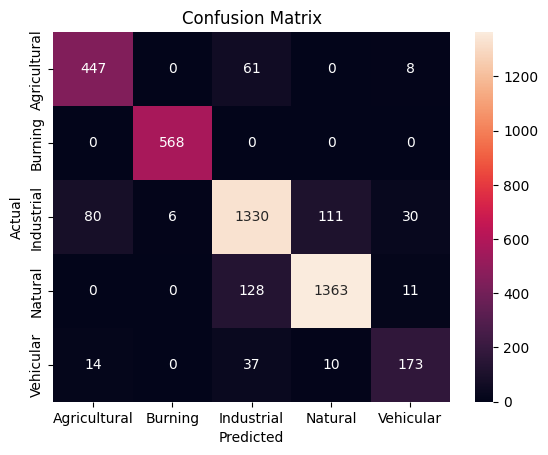

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=best_rf.classes_,
            yticklabels=best_rf.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [78]:
import joblib

joblib.dump(best_rf, "best_model.pkl")

['best_model.pkl']

In [83]:
sample_df = df.sample(2000)

In [84]:
import folium

map_center = [sample_df['Latitude'].mean(), sample_df['Longitude'].mean()]

m = folium.Map(
    location=map_center,
    zoom_start=5,
    tiles="CartoDB positron"
)

In [85]:
def get_color(source):
    if source == "Industrial":
        return "red"
    elif source == "Vehicular":
        return "blue"
    elif source == "Agricultural":
        return "green"
    elif source == "Burning":
        return "black"
    else:
        return "orange"

for i in range(len(sample_df)):
    folium.CircleMarker(
        location=[sample_df.iloc[i]['Latitude'], sample_df.iloc[i]['Longitude']],
        radius=4,
        color=get_color(sample_df.iloc[i]['pollution_source']),
        fill=True,
        fill_opacity=0.6,
        popup=sample_df.iloc[i]['pollution_source']
    ).add_to(m)

In [86]:
from folium.plugins import HeatMap

heat_data = sample_df[['Latitude', 'Longitude', 'AQI Value']].dropna().values.tolist()

HeatMap(heat_data).add_to(m)

In [87]:
m.save("pollution_map.html")

In [ ]:
import joblib

# Save models
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(dt_model, "dt_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

# Save column names (VERY IMPORTANT)
joblib.dump(list(X.columns), "columns.pkl")   

['columns.pkl']